# Pose Classification using MediaPipe Landmark Detection

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json
import seaborn as sns

In [ ]:
data = pd.read_csv('posedata_20260305_155724.csv')

X = data.drop('label', axis=1).values
y = data['label'].values

scaler = StandardScaler()
encoder = LabelEncoder()
y = encoder.fit_transform(y)

X = X.reshape(-1, 33, 2)

left_hip = X[:, 24]
right_hip = X[:, 23]

hip_center = (left_hip + right_hip) / 2
X = X - hip_center[:, None, :]

left_shoulder = X[:, 12]
right_shoulder = X[:, 11]

shoulder_center = (left_shoulder + right_shoulder) / 2

torso_length = np.linalg.norm(shoulder_center, axis=1)
torso_length = torso_length[:, None, None]

X = X / torso_length

X = X.reshape(-1, 66)

X = scaler.fit_transform(X)

# GROUP-BASED SPLIT

raw_labels = data['label'].values
segment_ids = np.zeros(len(raw_labels), dtype=int)
segment = 0
for i in range(1, len(raw_labels)):
    if raw_labels[i] != raw_labels[i - 1]:
        segment += 1
    segment_ids[i] = segment

# Each cycle has 4 classes
n_classes = len(np.unique(y))
cycle_ids = segment_ids // n_classes

print(f"Total segments: {segment + 1}")
print(f"Total cycles: {cycle_ids.max() + 1}")
print(f"Samples per cycle:")
for c in range(cycle_ids.max() + 1):
    mask = cycle_ids == c
    print(f"  Cycle {c}: {mask.sum()} samples, classes: {dict(zip(*np.unique(y[mask], return_counts=True)))}")

# Use last cycle as test, rest as train
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=cycle_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# Verify no cycle overlap
train_cycles = set(cycle_ids[train_idx])
test_cycles = set(cycle_ids[test_idx])
print(f"\nTrain cycles: {sorted(train_cycles)}")
print(f"Test cycles:  {sorted(test_cycles)}")
print(f"Overlap: {len(train_cycles & test_cycles)} (should be 0)")


X_train_tensor = torch.tensor(X_train).float()
y_train_tensor = torch.tensor(y_train).long()

X_test_tensor = torch.tensor(X_test).float()
y_test_tensor = torch.tensor(y_test).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

# end of GROUP-BASED SPLIT


######################################################################################################### 
### TRAIN VAL TEST SPLIT 
### 

# # 1. INITIAL SPLIT (Separate Test set entirely)
# X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# # 2. SECOND SPLIT (Split remaining into Train and Val)
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

# # 3. PREVENT LEAKAGE: Fit scaler ONLY on training data
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

# # 4. CONVERT TO TENSORS
# X_train_tensor = torch.tensor(X_train).float()
# y_train_tensor = torch.tensor(y_train).long()
# X_val_tensor = torch.tensor(X_val).float()
# y_val_tensor = torch.tensor(y_val).long()
# X_test_tensor = torch.tensor(X_test).float()
# y_test_tensor = torch.tensor(y_test).long()

# # 5. DATALOADERS
# train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
# val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
# test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

### 
### END: TRAIN VAL TEST SPLIT 
################################################################################################

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train_tensor = torch.tensor(X_train).float()
# y_train_tensor = torch.tensor(y_train).long()

# X_test_tensor = torch.tensor(X_test).float()
# y_test_tensor = torch.tensor(y_test).long()

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader  = DataLoader(test_dataset, batch_size=32)

class PoseClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(66, 128),
            #nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

model = PoseClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
learning_rate = 1e-3
batch_size = 64
epochs = 50



def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, criterion, optimizer)
    test_loop(test_loader, model, criterion)
print("Done!")



Total segments: 16
Total cycles: 4
Samples per cycle:
  Cycle 0: 5334 samples, classes: {np.int64(0): np.int64(1185), np.int64(1): np.int64(1810), np.int64(2): np.int64(1171), np.int64(3): np.int64(1168)}
  Cycle 1: 6099 samples, classes: {np.int64(0): np.int64(1939), np.int64(1): np.int64(1311), np.int64(2): np.int64(1473), np.int64(3): np.int64(1376)}
  Cycle 2: 5779 samples, classes: {np.int64(0): np.int64(1138), np.int64(1): np.int64(1597), np.int64(2): np.int64(1552), np.int64(3): np.int64(1492)}
  Cycle 3: 5855 samples, classes: {np.int64(0): np.int64(1209), np.int64(1): np.int64(1175), np.int64(2): np.int64(1526), np.int64(3): np.int64(1945)}

Train cycles: [np.int64(0), np.int64(2), np.int64(3)]
Test cycles:  [np.int64(1)]
Overlap: 0 (should be 0)
Epoch 1
-------------------------------
loss: 1.407613  [   32/16968]
loss: 0.114724  [ 6432/16968]
loss: 0.014031  [12832/16968]
loss: 0.076828  [19232/16968]
loss: 0.000463  [25632/16968]
loss: 0.000768  [32032/16968]
Test Error: 
 

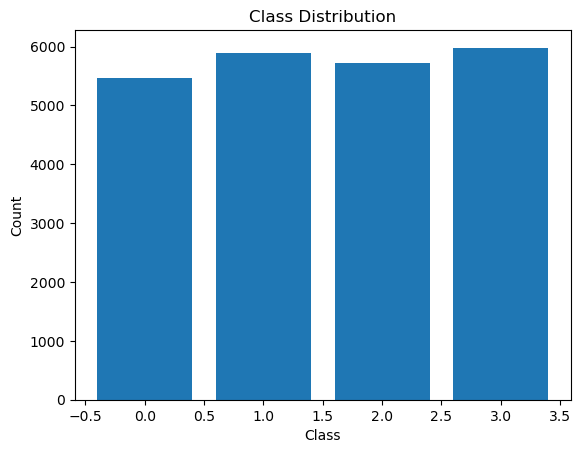

In [22]:
# Exploratory data analysis
# Class distribution 
unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show() 


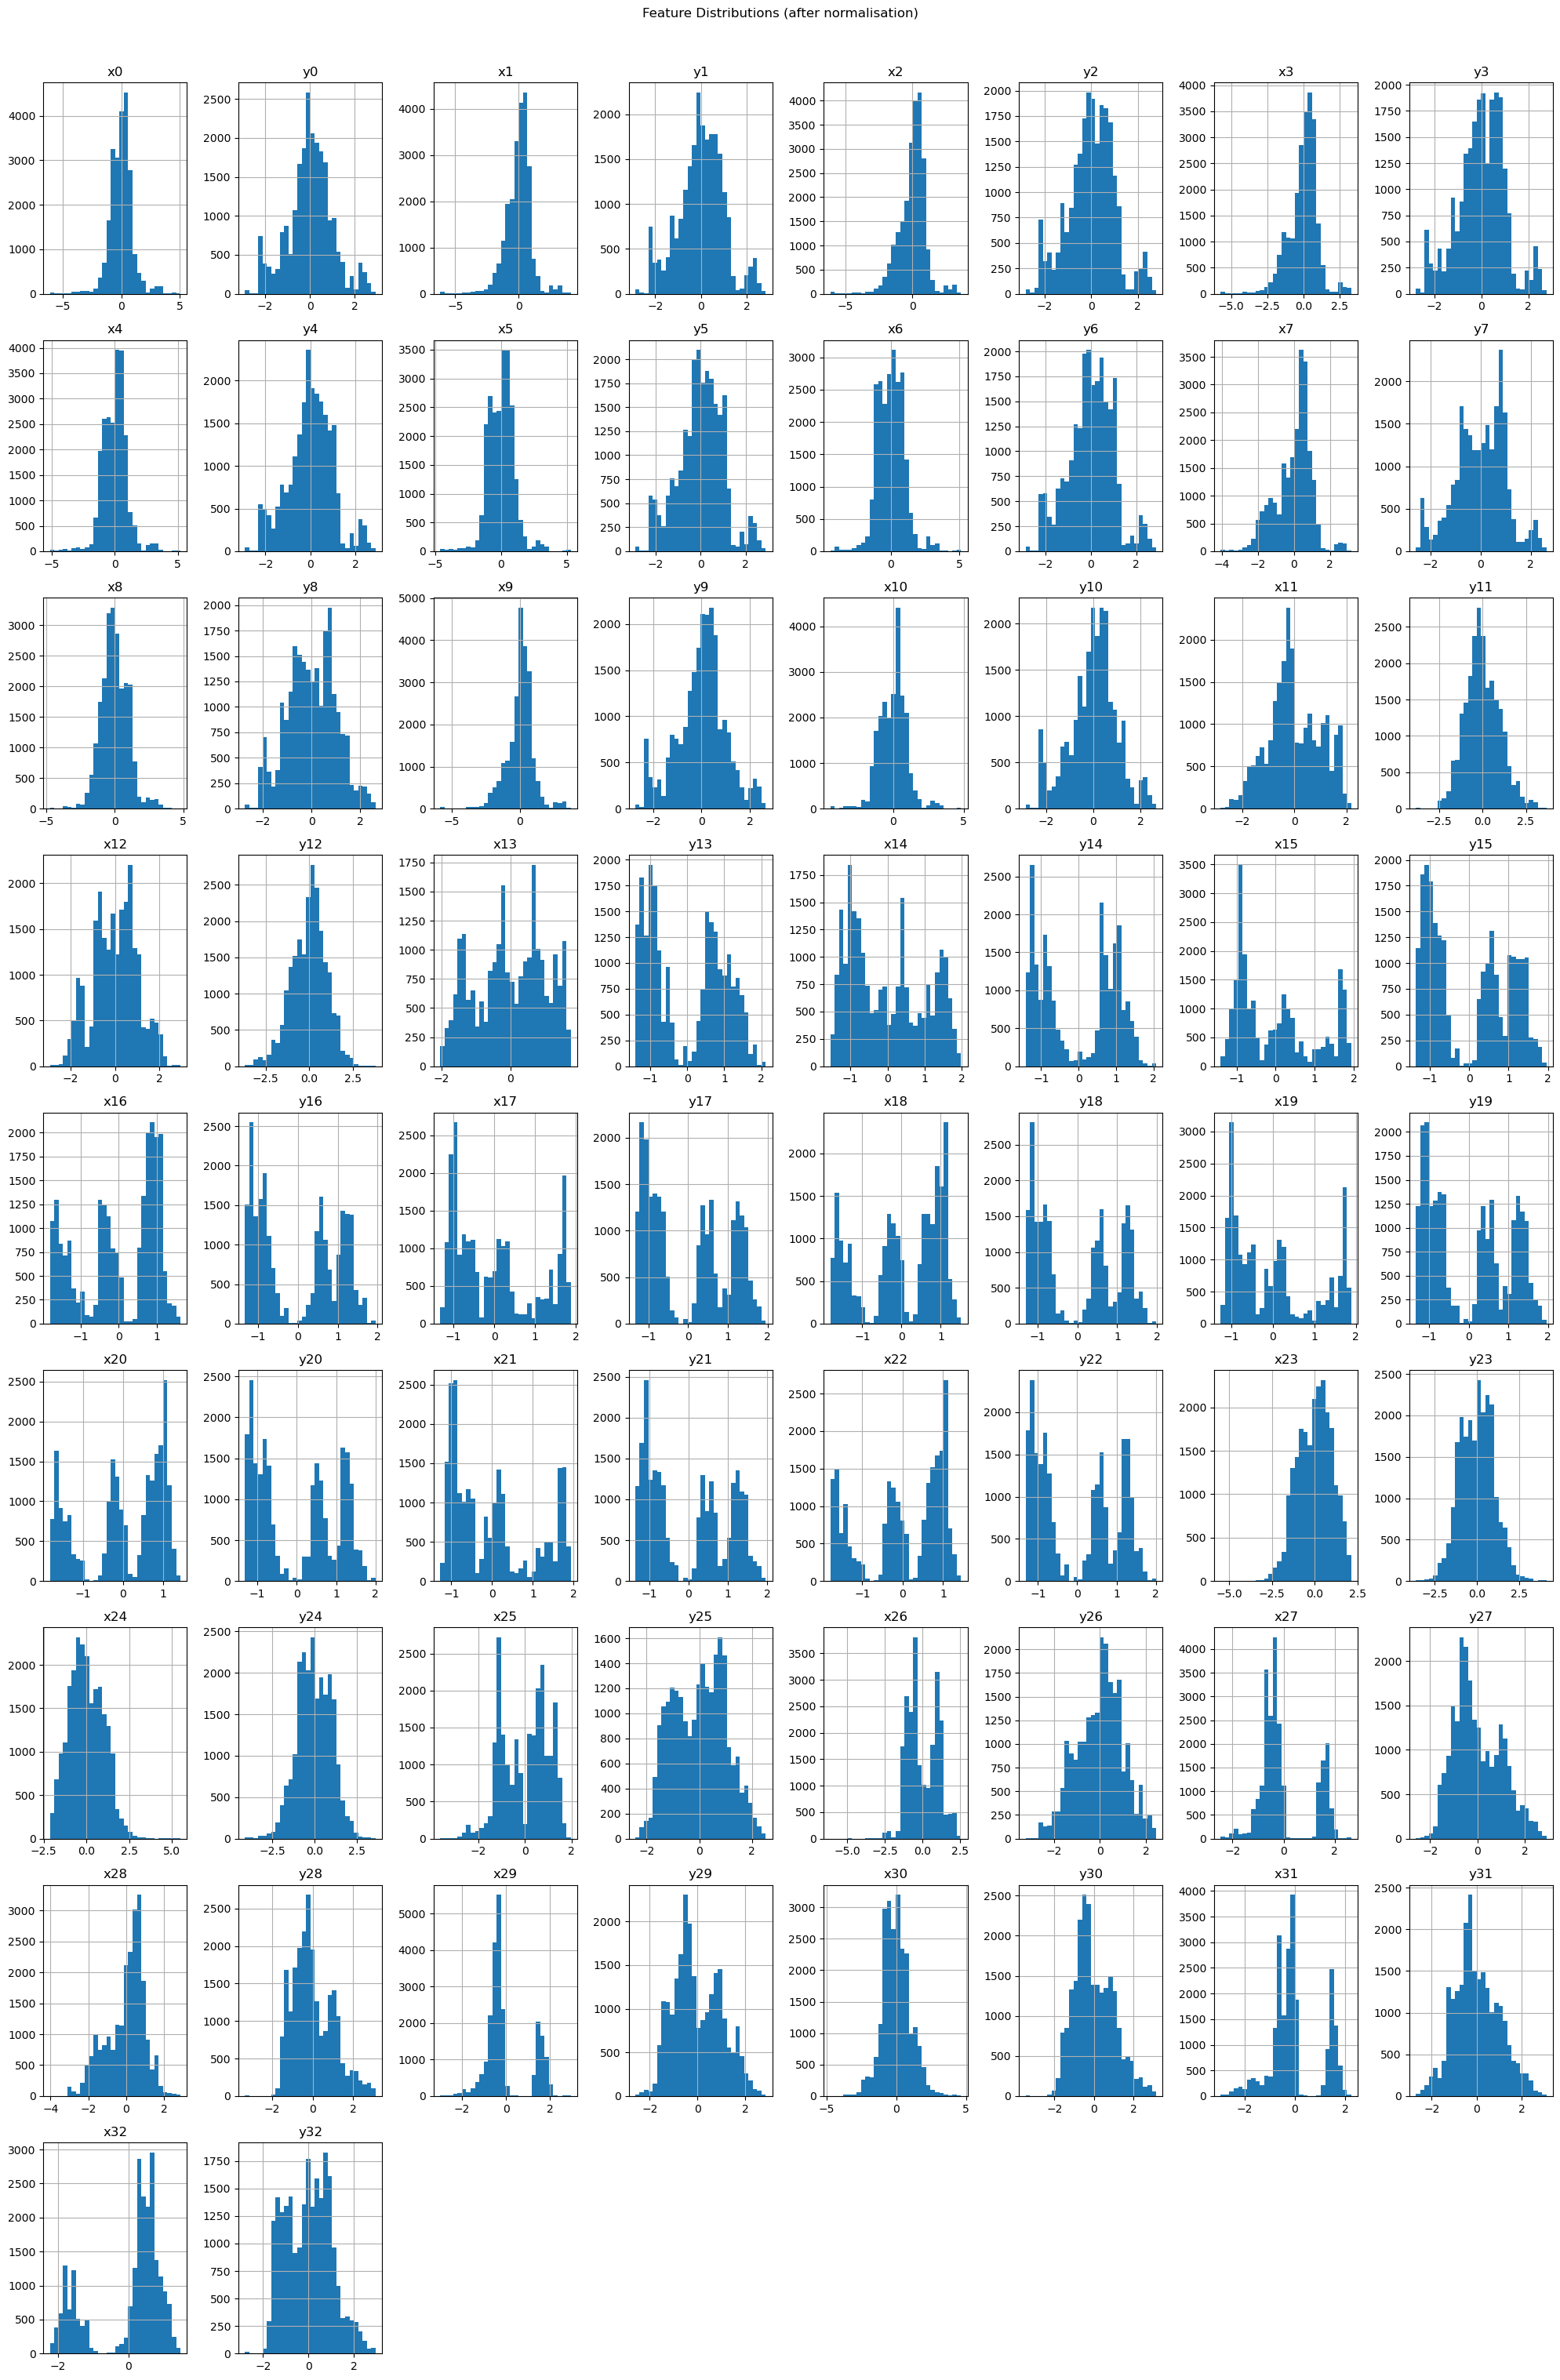

In [23]:
# Explore if data is similar ranges
feature_names = [col for col in data.columns if col != 'label']
df_scaled = pd.DataFrame(X, columns=feature_names)

df_scaled.hist(bins=30, figsize=(20, 30))
plt.suptitle("Feature Distributions (after normalisation)", y=1.01)
plt.tight_layout()
plt.show()

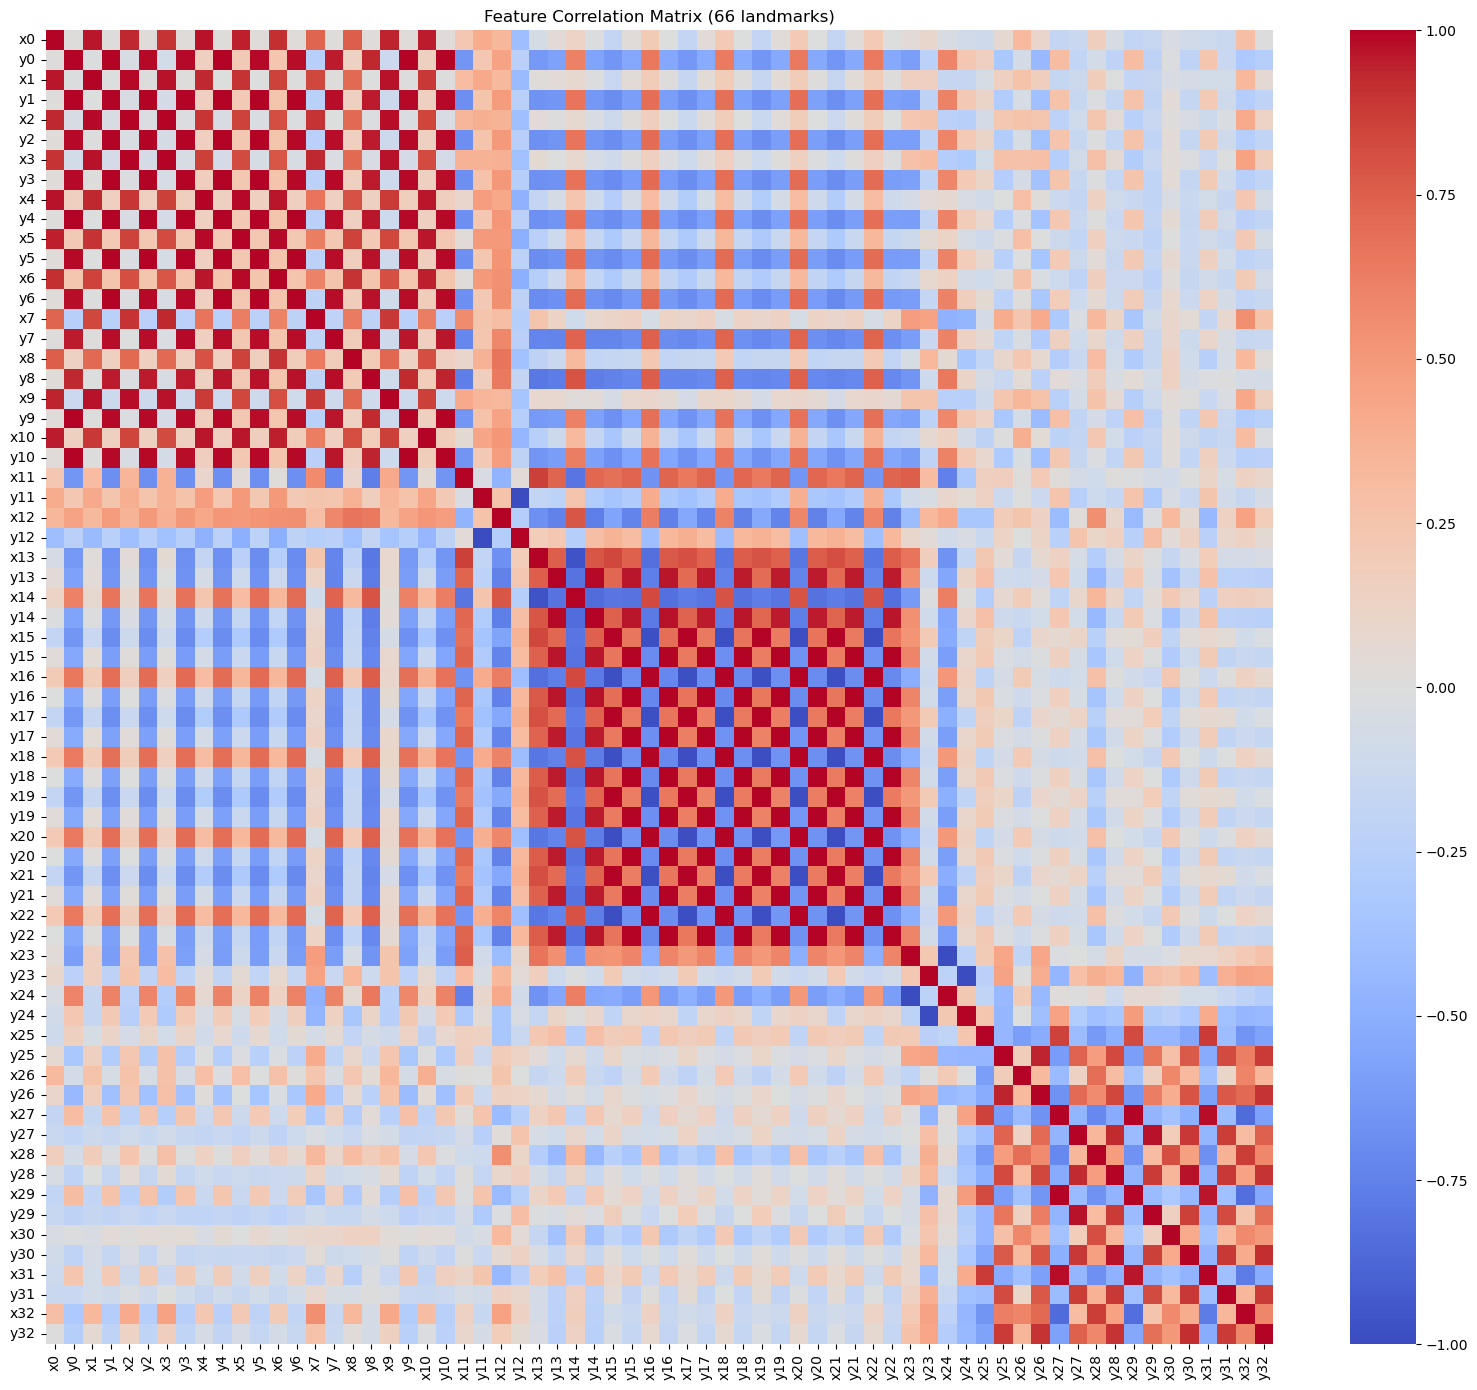


Highly correlated pairs (|r| > 0.95): 149
  x0 <-> x1: 0.967
  x0 <-> x4: 0.975
  x0 <-> x10: 0.955
  y0 <-> y1: 0.994
  y0 <-> y2: 0.992
  y0 <-> y3: 0.989
  y0 <-> y4: 0.992
  y0 <-> y5: 0.988
  y0 <-> y6: 0.983
  y0 <-> y7: 0.960


In [ ]:

# 3. CORRELATION MATRIX — which landmarks are redundant

corr = df_scaled.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (66 landmarks)")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nHighly correlated pairs (|r| > 0.95): {len(high_corr)}")
for f1, f2, r in high_corr[:10]:
    print(f"  {f1} <-> {f2}: {r:.3f}")

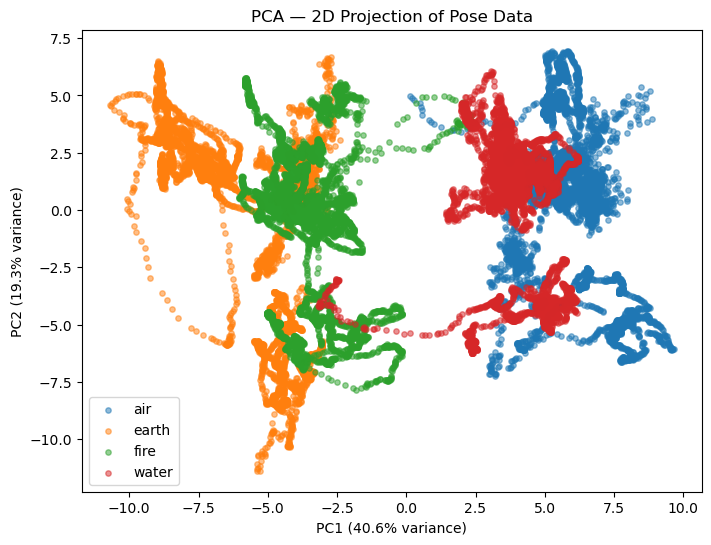

In [ ]:
# 4. PCA

from sklearn.decomposition import PCA
class_names = encoder.classes_
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for c in np.unique(y):
    mask = y == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_names[c], alpha=0.5, s=15)

plt.legend()
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA — 2D Projection of Pose Data")
plt.show()

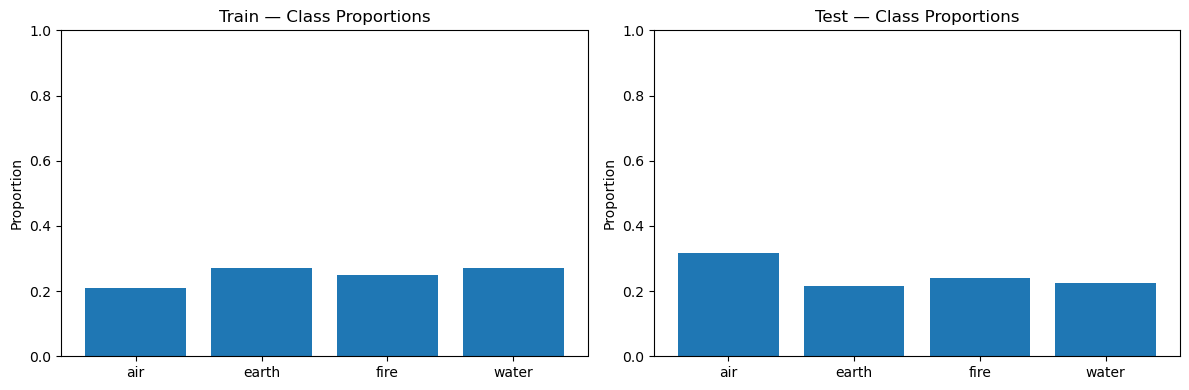

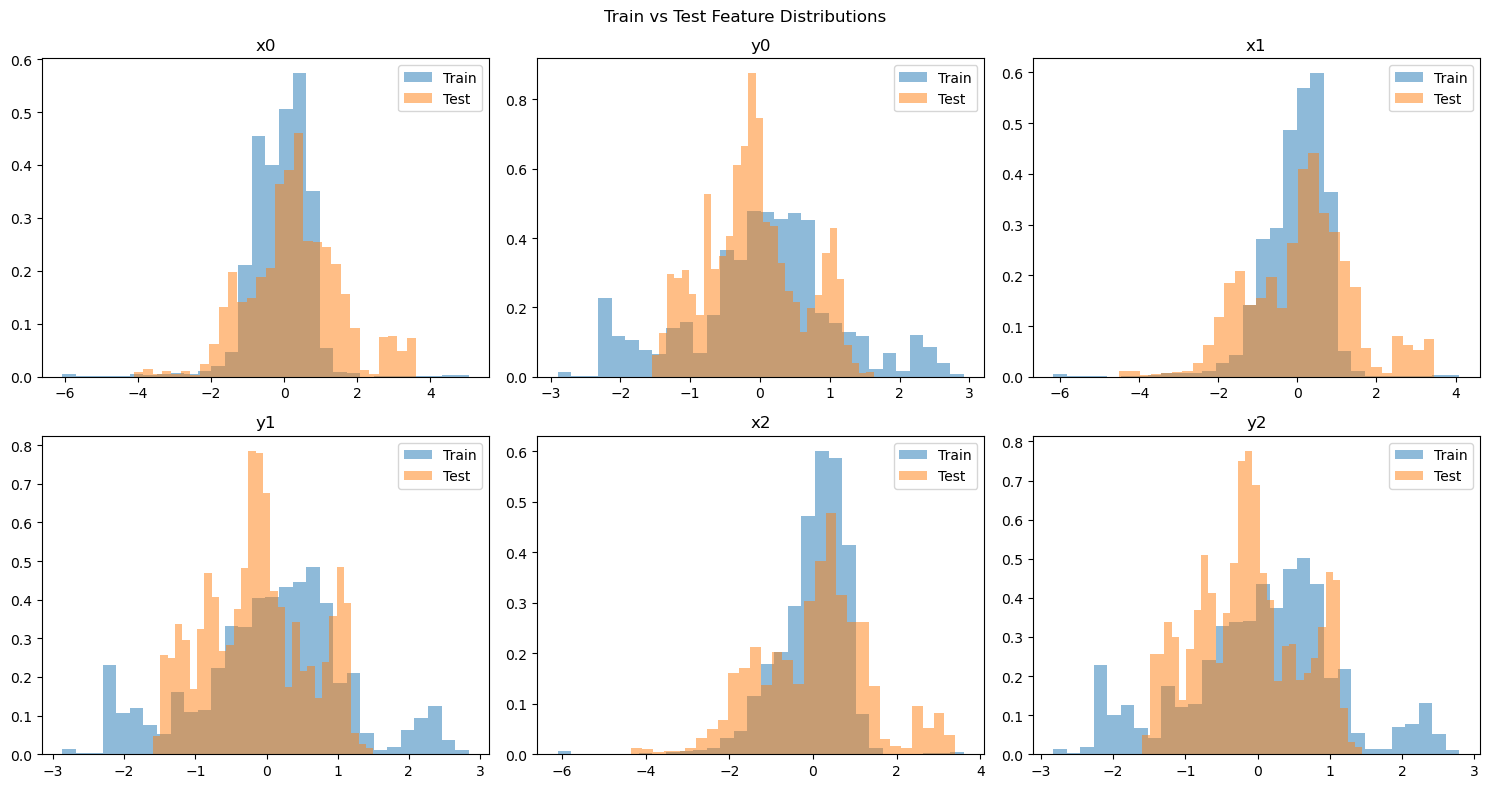

Features with significantly different train/test distributions: 66/66


In [ ]:
# 5. SPLIT VERIFICATION - train and test distributions


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unique_tr, counts_tr = np.unique(y_train, return_counts=True)
unique_te, counts_te = np.unique(y_test, return_counts=True)

axes[0].bar(class_names[unique_tr], counts_tr / len(y_train))
axes[0].set_title("Train — Class Proportions")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)

axes[1].bar(class_names[unique_te], counts_te / len(y_test))
axes[1].set_title("Test — Class Proportions")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Feature distribution comparison (first 6 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].hist(X_train[:, i], bins=30, alpha=0.5, label="Train", density=True)
    axes[i].hist(X_test[:, i], bins=30, alpha=0.5, label="Test", density=True)
    axes[i].set_title(feature_names[i])
    axes[i].legend()
plt.suptitle("Train vs Test Feature Distributions")
plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import ks_2samp
mismatches = 0
for i in range(X_train.shape[1]):
    stat, p_value = ks_2samp(X_train[:, i], X_test[:, i])
    if p_value < 0.05:
        mismatches += 1
print(f"Features with significantly different train/test distributions: {mismatches}/{X_train.shape[1]}")

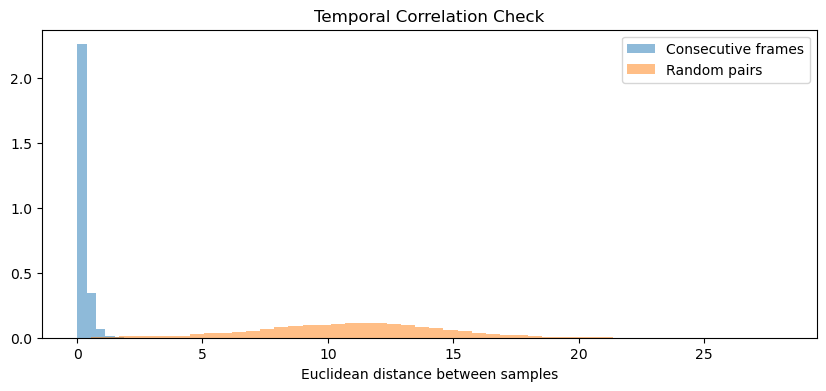

Median distance between consecutive frames: 0.150
Median distance between random pairs: 11.028
Ratio: 73.6x


In [ ]:
# TEMPORAL LEAKAGE CHECK — similarity of consecutive samples


# Computes distance between consecutive frames in the org data
consecutive_dists = np.linalg.norm(X[1:] - X[:-1], axis=1)
random_pairs = np.random.choice(len(X), size=(len(X)-1, 2), replace=True)
random_dists = np.linalg.norm(X[random_pairs[:, 0]] - X[random_pairs[:, 1]], axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(consecutive_dists, bins=50, alpha=0.5, label="Consecutive frames", density=True)
ax.hist(random_dists, bins=50, alpha=0.5, label="Random pairs", density=True)
ax.set_xlabel("Euclidean distance between samples")
ax.set_title("Temporal Correlation Check")
ax.legend()
plt.show()

print(f"Median distance between consecutive frames: {np.median(consecutive_dists):.3f}")
print(f"Median distance between random pairs: {np.median(random_dists):.3f}")
print(f"Ratio: {np.median(random_dists) / np.median(consecutive_dists):.1f}x")

In [29]:
class PoseClassifierWithSoftmax(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        logits = self.base_model(x)
        return self.softmax(logits)

model.eval()

export_model = PoseClassifierWithSoftmax(model)
export_model.eval()

torch.onnx.export(
    export_model,
    torch.randn(1, 66),
    "pose_classifier.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}
)

# scaler and labels export remain the same
scaler_params = {
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist()
}
with open("pose_scaler.json", "w") as f:
    json.dump(scaler_params, f)

label_mapping = {}
for i, name in enumerate(encoder.classes_):
    label_mapping[str(i)] = name

with open("pose_labels.json", "w") as f:
    json.dump(label_mapping, f)

print("Exported with softmax baked in — output is now probabilities [0, 1]")
print(f"Labels: {label_mapping}")

Exported with softmax baked in — output is now probabilities [0, 1]
Labels: {'0': 'air', '1': 'earth', '2': 'fire', '3': 'water'}
